In [1]:
import os
import torch
torch.set_default_dtype(torch.double)
import torchvision  
import matplotlib.pyplot as plt

# diffeomorphisms
from src.diffeomorphisms.image.starflow import StarFlowImageDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.euclidean.vector.standard import StandardVectorEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# training
from src.training.trimmed_ellipsoid_starflow import TrimmedEllipsoidStarFlowTraining

# settings
n_clusters = 10
trimmed = True

# results folder
results_folder = os.path.join("results", "mnist", "multi_trimmed_ellipsoidal_starflow", "{}_clusters".format(n_clusters) + ("_trimmed" if trimmed else ""))
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(31)

In [2]:
H = W = 28
mnist_mean = 0.1307
mnist_var = 0.3081

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Collect all images and labels
data = []
labels = []

for x, y in full_dataset:
    data.append(x)          # x has shape 1 x H x W
    labels.append(y)

# Stack into tensors
data = torch.stack(data, dim=0)        # shape: N x 1 x H x W
labels = torch.tensor(labels, dtype=torch.long)  # shape: N

print(data.shape, labels.shape)


torch.Size([60000, 1, 28, 28]) torch.Size([60000])


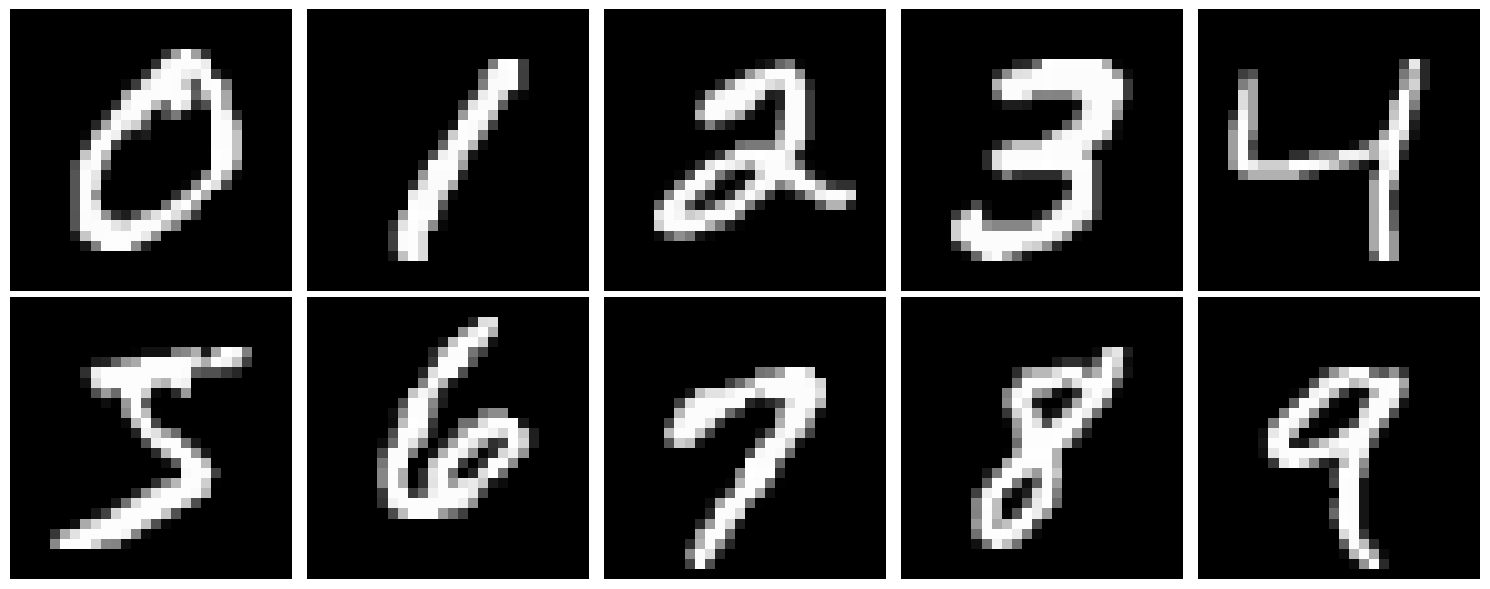

In [3]:
# construct data clusters as one digit per class
data_clusters = torch.zeros((10, 1, H, W))  # placeholder for cluster images
for digit in range(10):
    digit_indices = (labels == digit)
    data_clusters[digit] = data[digit_indices][0]

cluster_labels = torch.arange(10)

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(data_clusters[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
trainer = TrimmedEllipsoidStarFlowTraining(H*W, data, n_clusters, trimmed=trimmed, cov_reg=1e-12)

Data shape: torch.Size([60000, 1, 28, 28]), self.shape: torch.Size([1, 28, 28])


In [5]:
trainer.solve()
starflow = trainer.starflow

In [ ]:
phi = StarFlowImageDiffeomorphism(1, H, W, starflow, s=1.)
manifold = StandardPullbackImageEuclidean(phi)
l2_euclidean = StandardImageEuclidean(1, H, W)

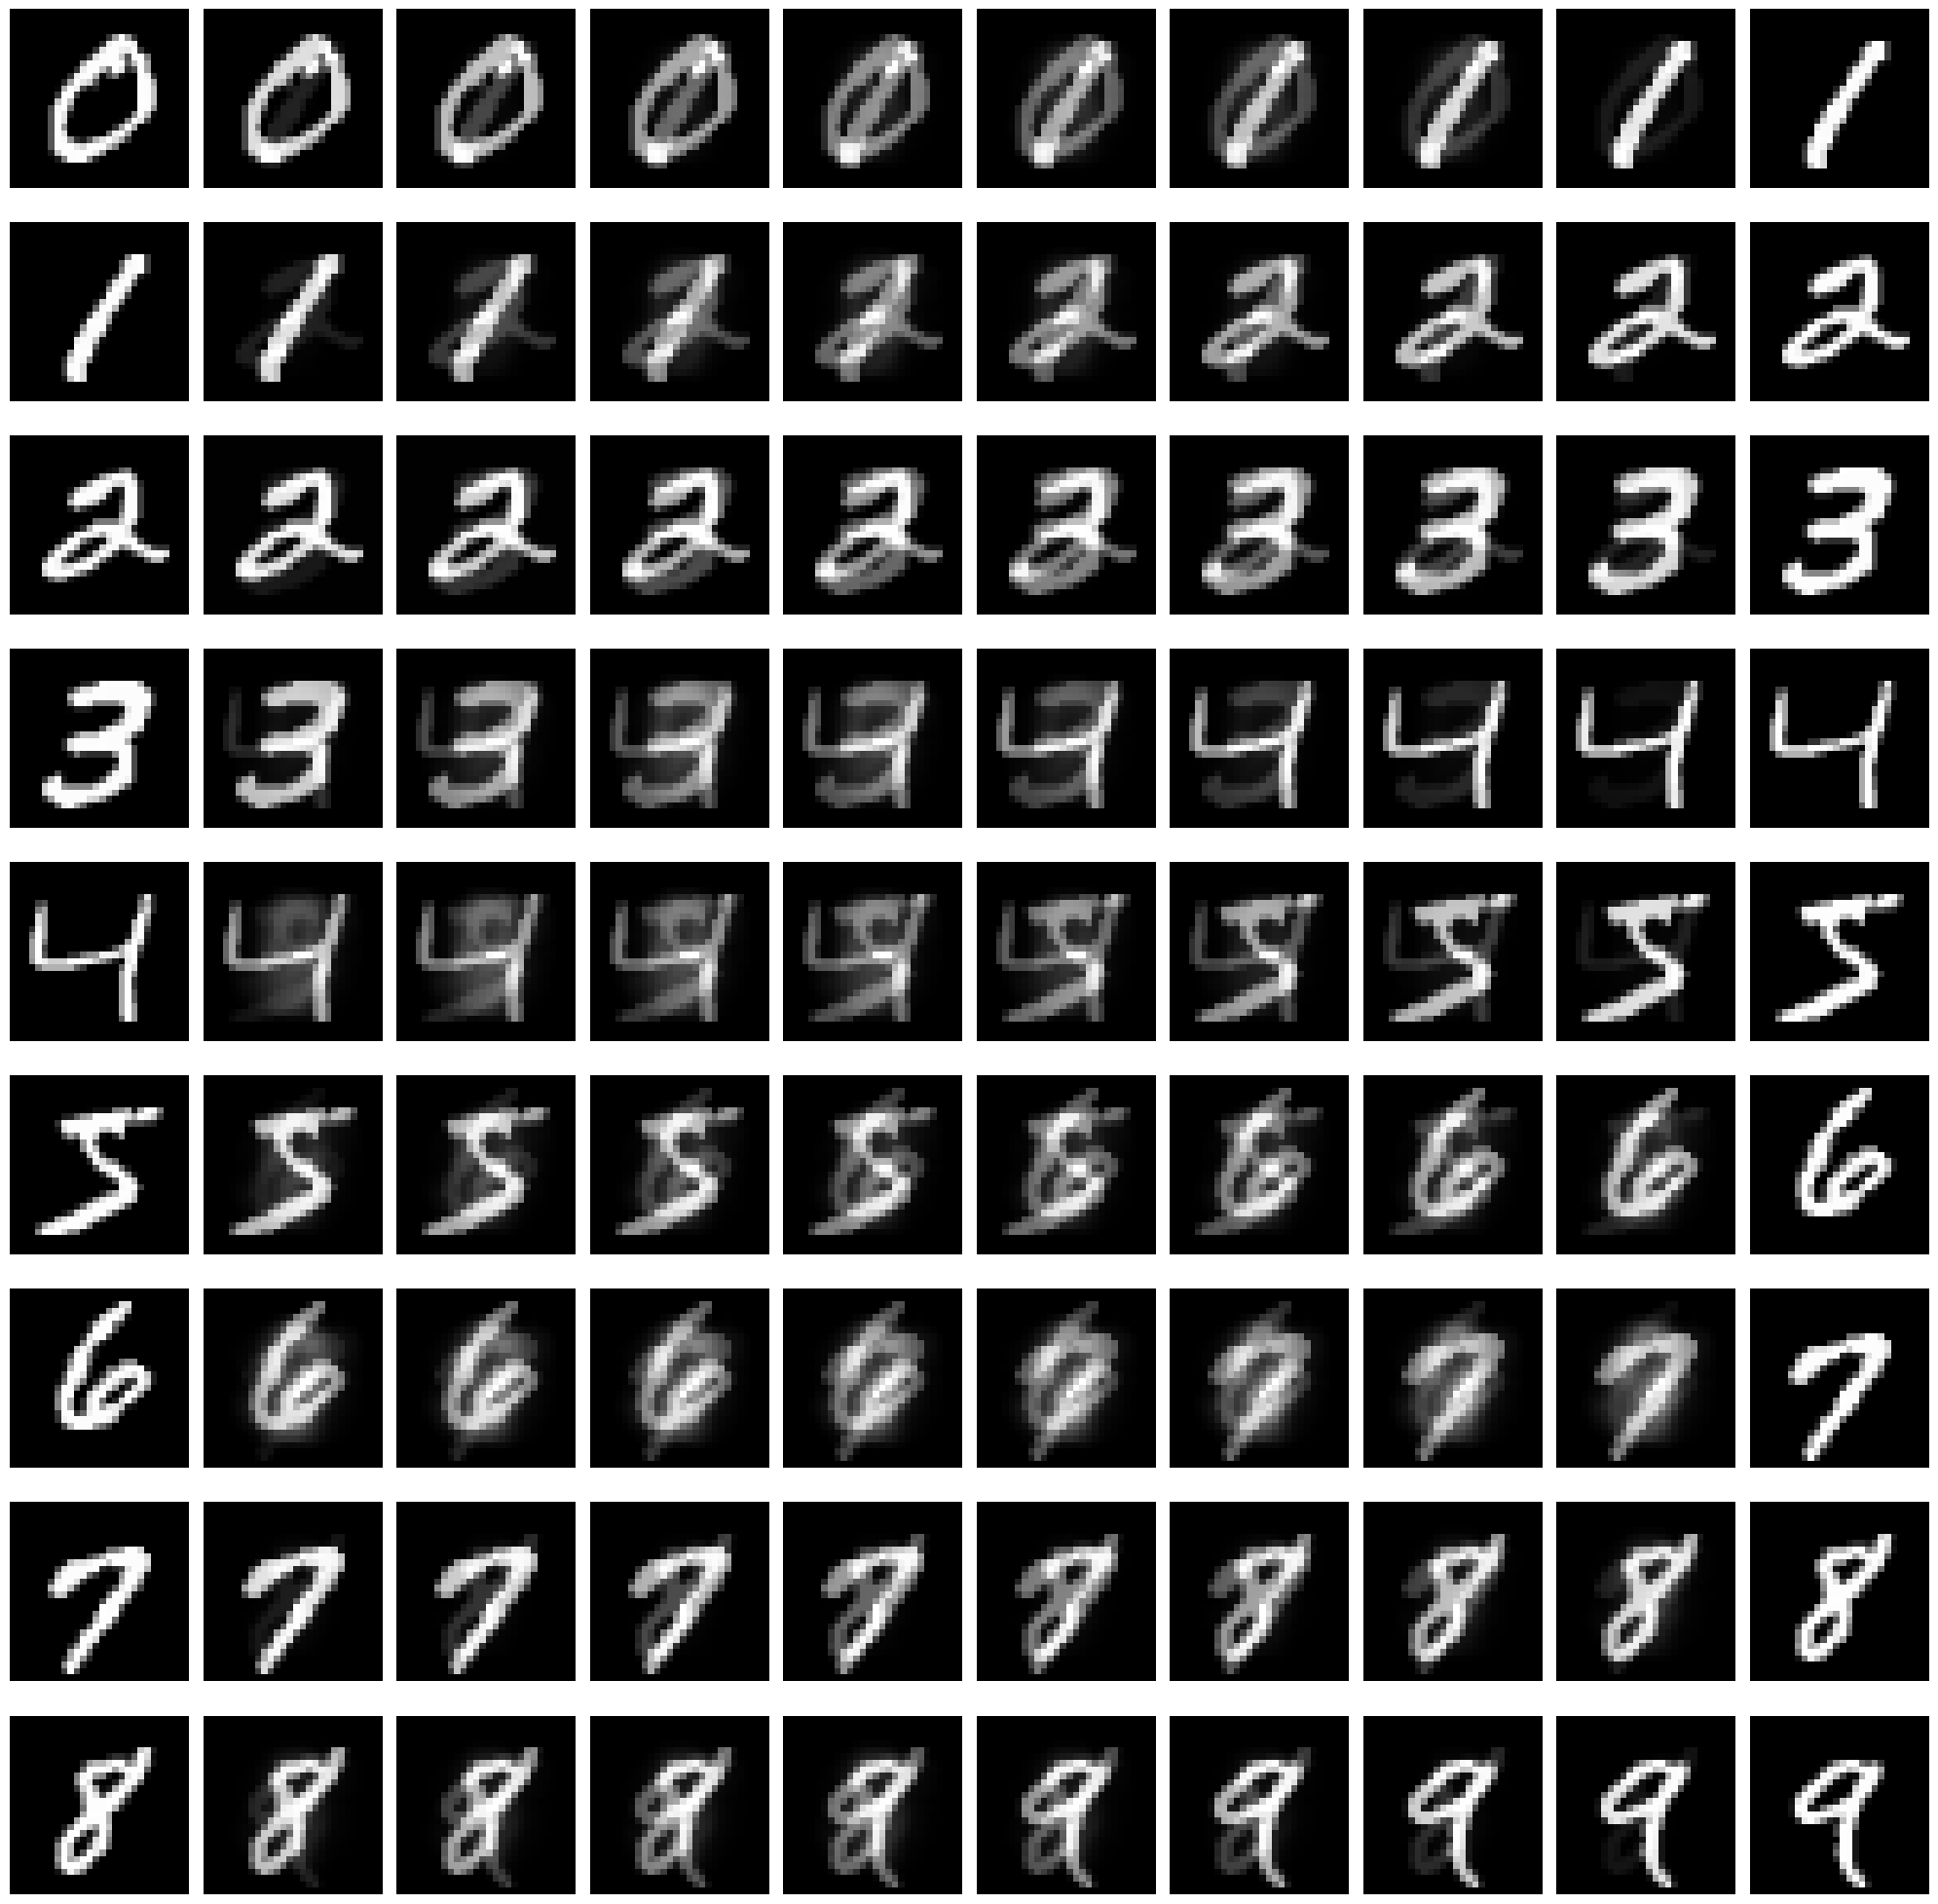

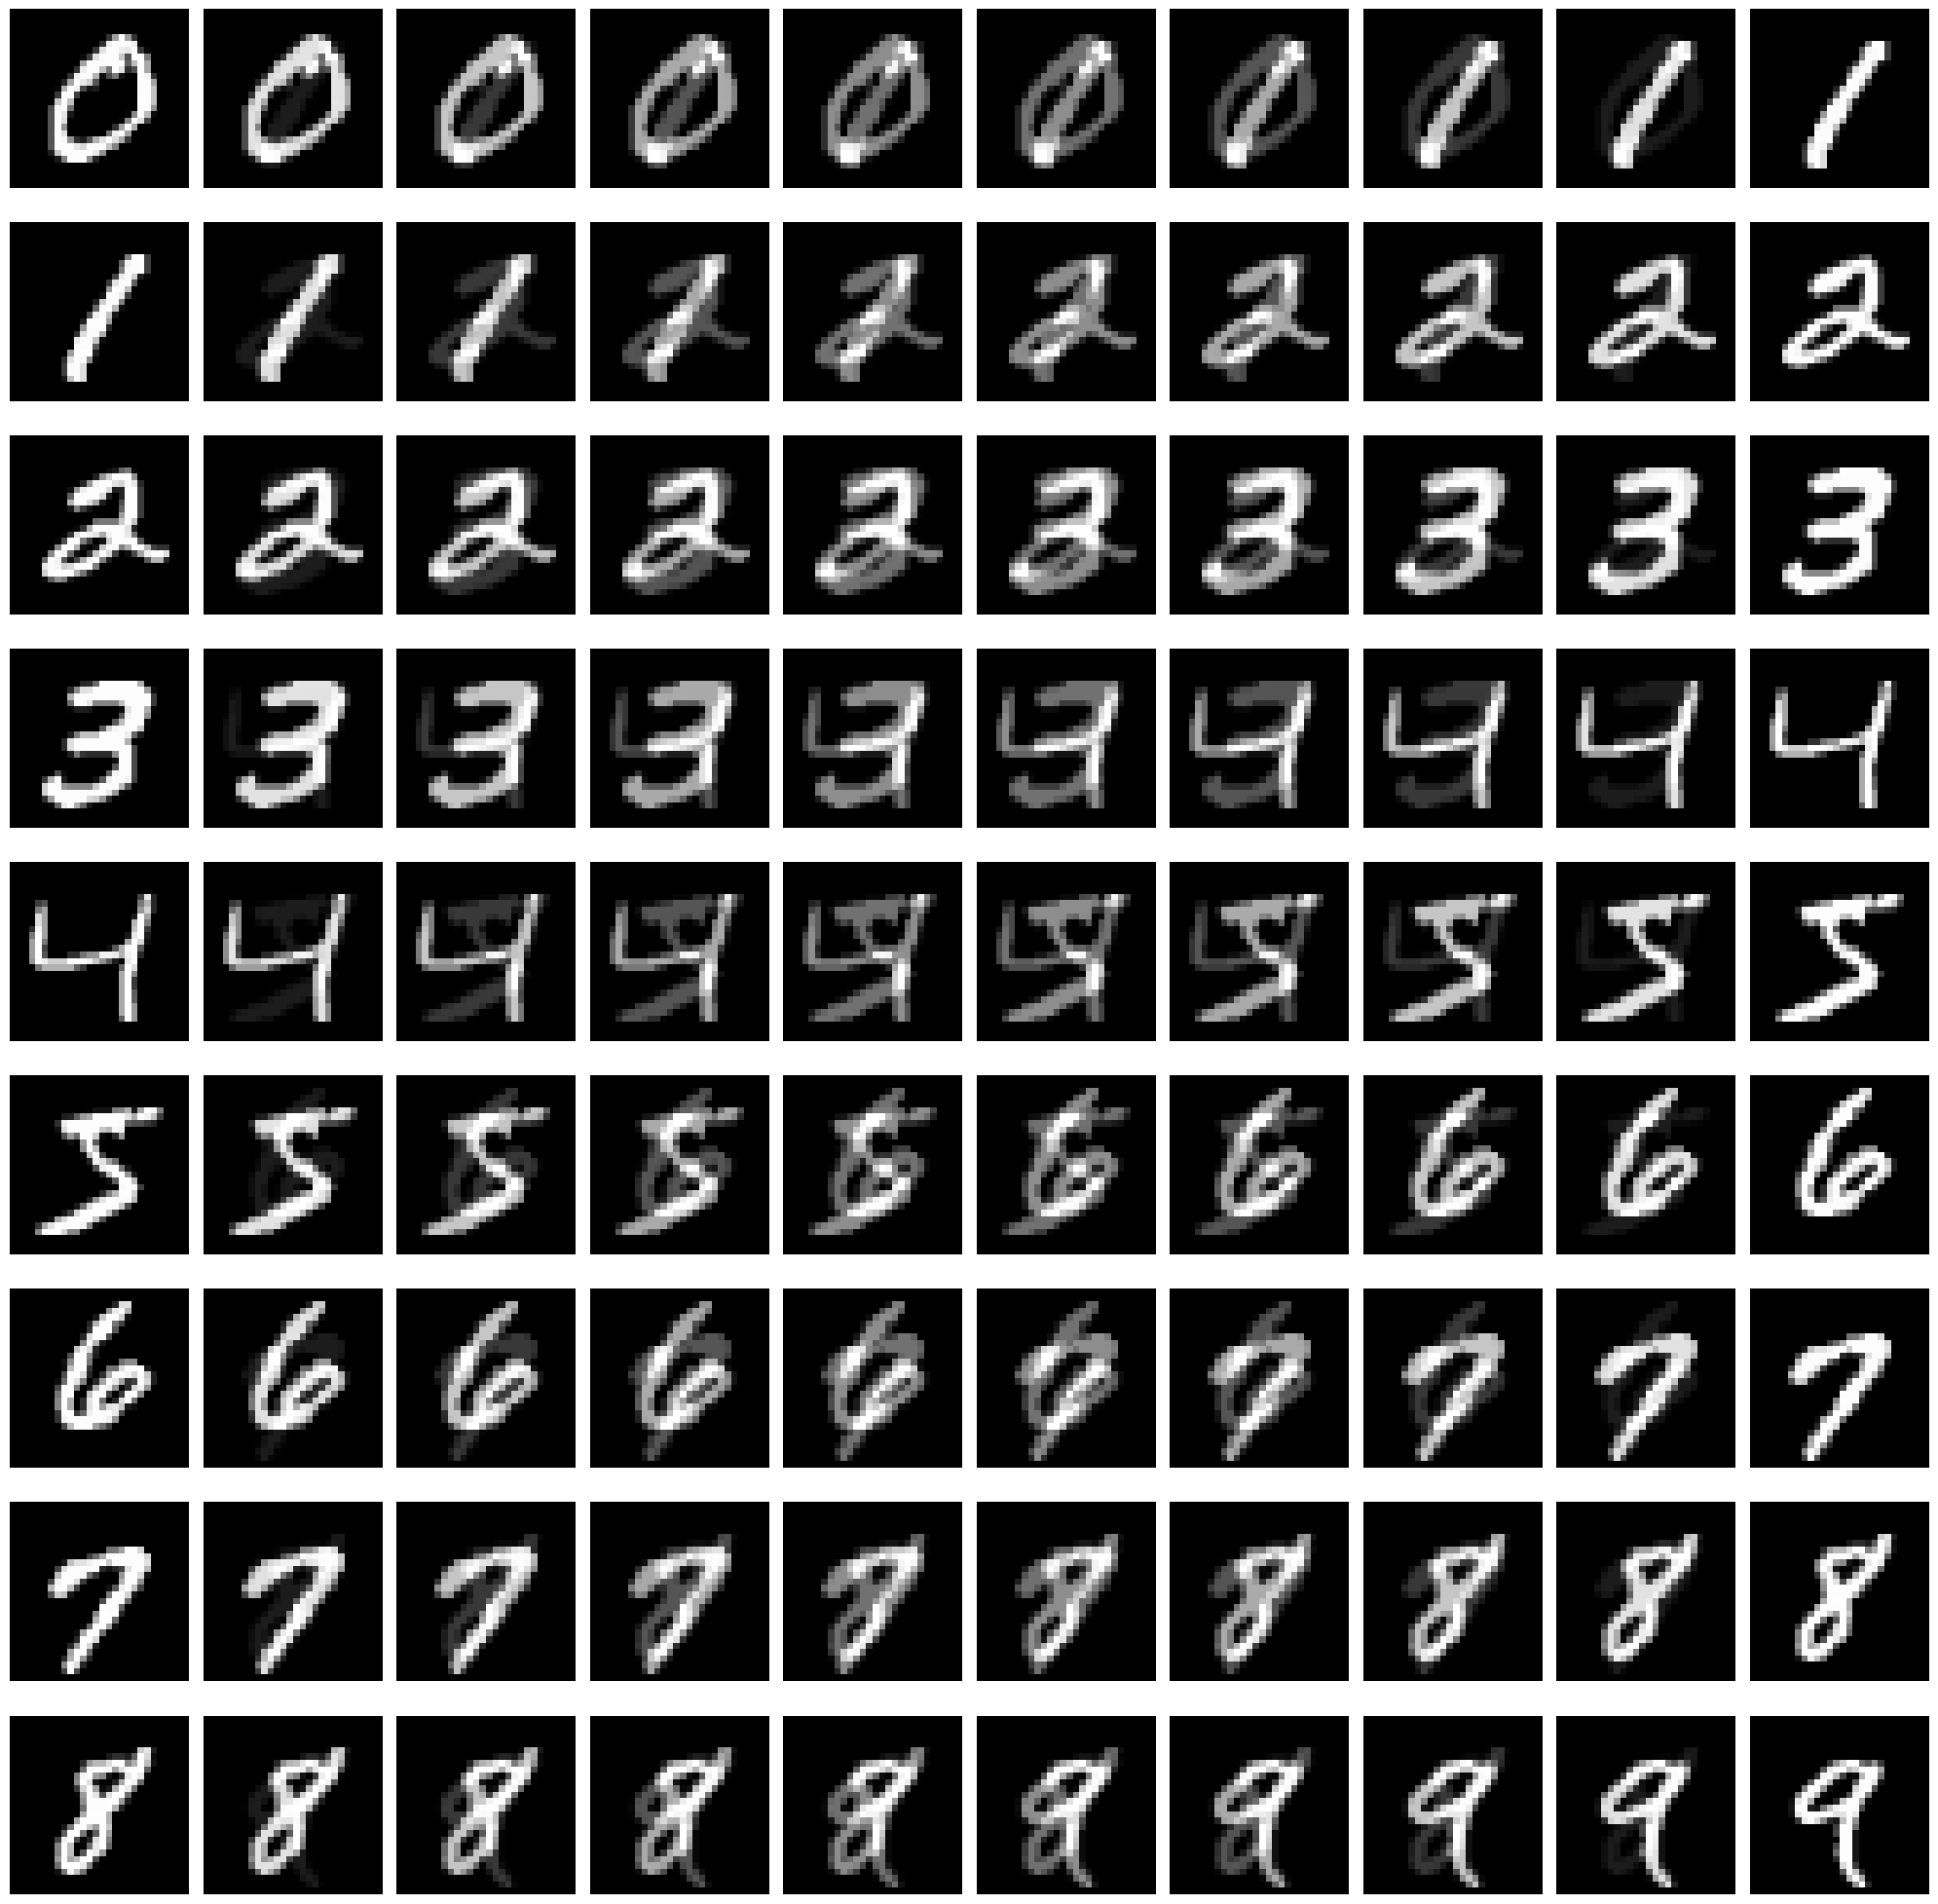

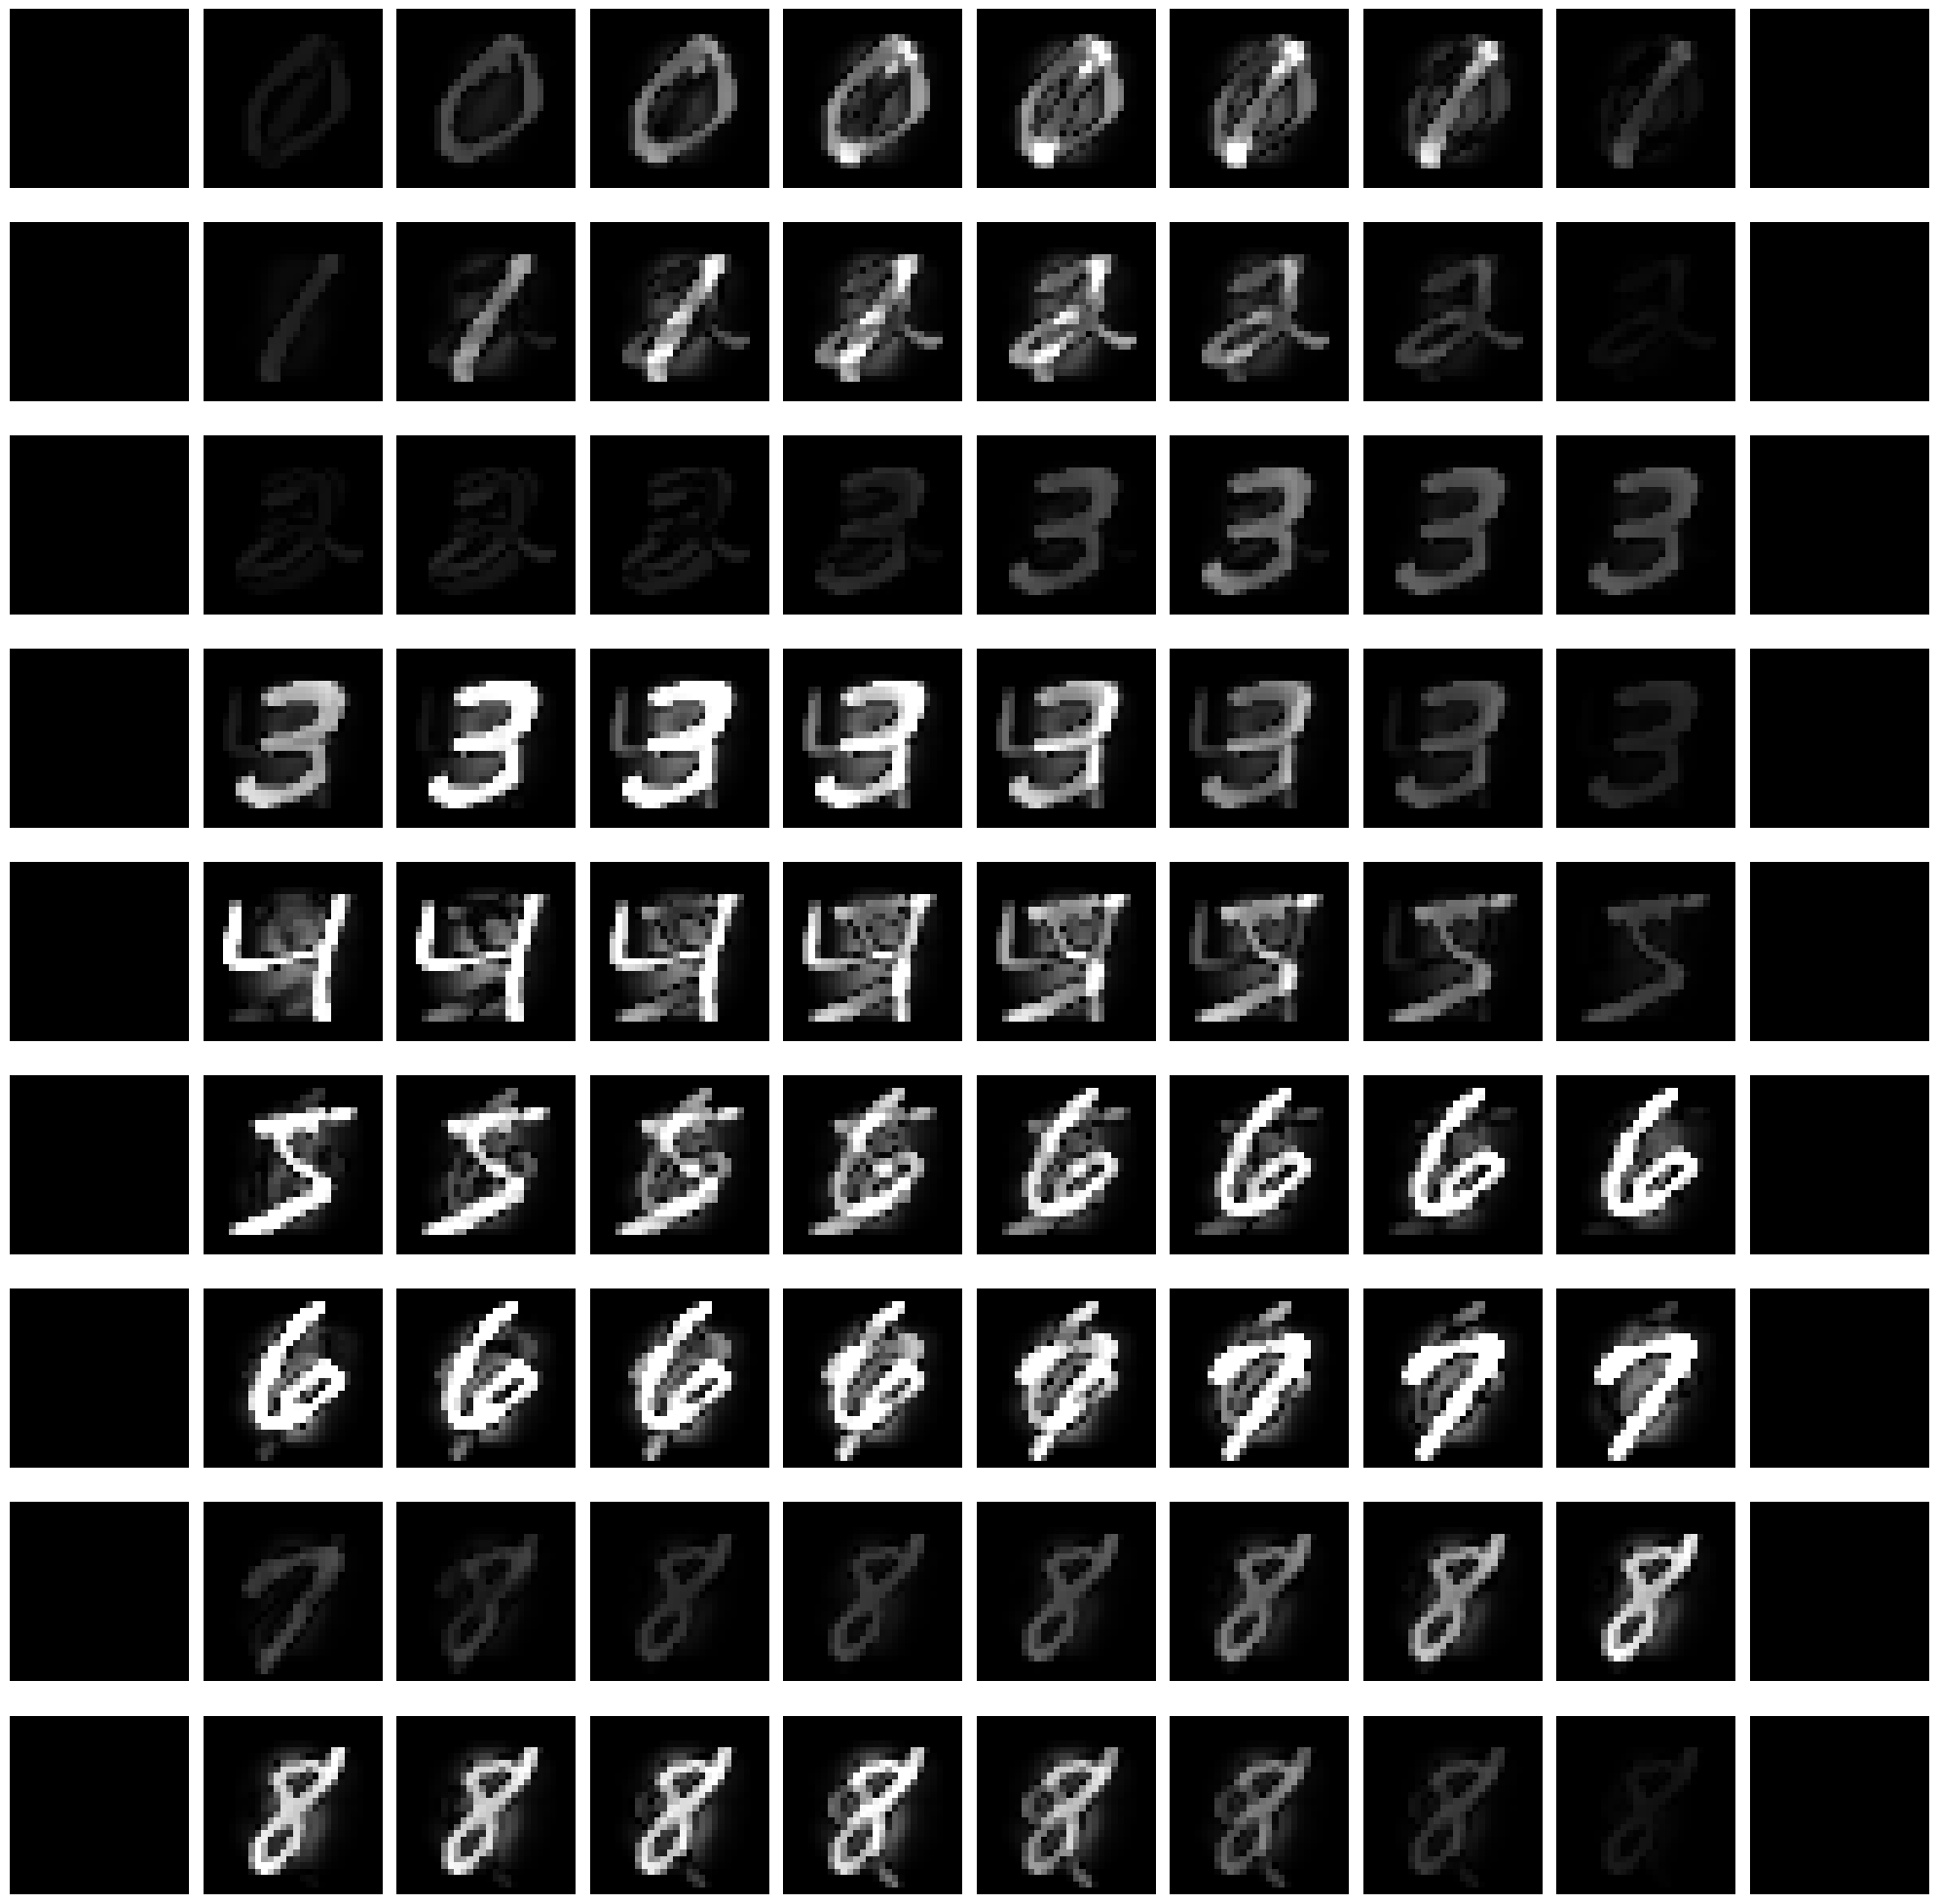

In [11]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    geodesics = manifold.geodesic(data_clusters[None], data_clusters[None], t)[0] 
    interpolations = l2_euclidean.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(geodesics[i, i+1, k, 0], cmap='gray')
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics.png"))
plt.show()

# plot interpolations
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow(interpolations[i, i+1, k, 0], cmap='gray')
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"linear_interpolations.png"))
plt.show()

# plot differences
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow((geodesics[i, i+1, k, 0] - interpolations[i, i+1, k, 0]).abs(), cmap='gray', vmin=0., vmax=1.)
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"differences.png"))
plt.show()